# Reference Microstructure Systems

Three reference beam-network architectures from the literature:

| # | Structure | Reference |
|---|-----------|----------|
| 1 | **E-Voronoi** — eroded Voronoi tessellation | Hooshmand-Ahoor et al. (2022) |
| 3 | **k-nearest foam** — procedural beam network with anisotropic metric | Martínez et al. (2017) |

Run cells top-to-bottom. Each section defines functions first, then executes them.

---
## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from scipy.spatial import Voronoi
from scipy.spatial import cKDTree
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

from shapely.geometry import Point, LineString, Polygon

import numpy as np
from stl import mesh
from shapely.geometry import Polygon
from shapely.ops import unary_union

import random

Imports OK


In [3]:
from shapely.geometry import Point, LineString, Polygon

import numpy as np
from stl import mesh
from shapely.ops import unary_union
import trimesh

# Function to convert 2D polygon to 3D mesh by adding thickness
def polygon_to_3d_mesh(polygon, thickness=1.0):
    # Get the exterior coordinates of the 2D polygon
    exterior_coords = list(polygon.exterior.coords)
    
    # Create vertices for the top and bottom of the 3D shape
    top_vertices = [(x, y, thickness) for x, y in exterior_coords]
    bottom_vertices = [(x, y, 0) for x, y in exterior_coords]
    
    # Vertices array: two sets of vertices (top and bottom)
    vertices = np.array(top_vertices + bottom_vertices)
    
    # Number of points in the polygon
    n = len(exterior_coords)
    
    # Create faces (triangles) connecting the top and bottom surfaces
    faces = []
    
    # Create side walls
    for i in range(n):
        next_i = (i + 1) % n
        faces.append([i, next_i, n + next_i])   # Top to bottom
        faces.append([i, n + next_i, n + i])    # Bottom to top
    
    # Create top and bottom surfaces
    for i in range(1, n - 1):
        faces.append([0, i+1, i ])#[0, i, i + 1])             # Top face
        faces.append([n, n + i, n + i+1]) #[n, n + i, n + i + 1])     # Bottom face

    # Convert faces to NumPy array
    faces = np.array(faces)
    
    # Create mesh object
    polygon_mesh = mesh.Mesh(np.zeros(faces.shape[0], dtype=mesh.Mesh.dtype))
    
    for i, face in enumerate(faces):
        for j in range(3):
            polygon_mesh.vectors[i][j] = vertices[face[j], :]
    
    return polygon_mesh

def merge_3d_meshes(mesh_list):
    # List to hold the vertices and faces of the merged mesh
    vertices = []
    faces = []
    
    # Variable to track the current offset for the face indices
    vertex_offset = 0
    
    # Iterate over each mesh and extract its vertices and faces
    for m in mesh_list:
        # Extract the vertices and faces of the current mesh
        current_vertices = m.vectors.reshape(-1, 3)  # Each face is a set of 3 vertices
        current_faces = np.arange(len(current_vertices)).reshape(-1, 3)
        
        # Append the vertices, and adjust the face indices by the current offset
        vertices.append(current_vertices)
        faces.append(current_faces + vertex_offset)
        
        # Update the vertex offset for the next mesh
        vertex_offset += len(current_vertices)
    
    # Concatenate all the vertices and faces into a single array
    vertices = np.vstack(vertices)
    faces = np.vstack(faces)
    
    # Create a new merged mesh
    merged_mesh = mesh.Mesh(np.zeros(faces.shape[0], dtype=mesh.Mesh.dtype))
    
    # Fill the new mesh with the vertices and faces
    for i, face in enumerate(faces):
        for j in range(3):
            merged_mesh.vectors[i][j] = vertices[face[j], :]
    
    return merged_mesh

def save_stl(poly_dict, out_plane_thickness, name, f_x=1, f_y = 1, frame_thickness = None):
    mesh_list = []
    for k,v in poly_dict.items():
        p = [] 
        for j in v:
            try: 
                p.append((float(j[0]), float(j[1])))
            except:
                None
        
        mesh_list.append(polygon_to_3d_mesh(Polygon(p), thickness=out_plane_thickness))
    
    if frame_thickness != None:
        t = frame_thickness
        bottom = Polygon([ (0,0-t), (0,0),(f_x,0),(f_x,0-t)])
        top = Polygon([(0,f_y),(0,f_y+t), (f_x,f_y+t), (f_x,f_y)])
        #right = Polygon([(f_x,0-t), (f_x,f_y+t), (f_x+t,f_y+t), (f_x+t,0-t)])
        #left = Polygon([(0-t,0-t),(0-t,f_y+t), (0,f_y+t), (0,0-t)])

        f = [bottom,top]#,  right, left]

        for f_ in f:            
            mesh_list.append(polygon_to_3d_mesh(f_, thickness=out_plane_thickness))

    merged_mesh = merge_3d_meshes(mesh_list)

    # Save the merged mesh as an STL file   
    merged_mesh.save(name)

def thicken_edge(p1, p2, width, bounding_box = None):
    """Create a polygon band around a line segment from p1 to p2."""
    p1 = np.array(p1)
    p2 = np.array(p2)
    direction = p2 - p1
    direction = direction / np.linalg.norm(direction)  # Normalize

    # Get normal vector
    normal = np.array([-direction[1], direction[0]])

    # Offset points
    p1_left = p1 + (width / 2) * normal
    p1_right = p1 - (width / 2) * normal
    p2_left = p2 + (width / 2) * normal
    p2_right = p2 - (width / 2) * normal

    # Build the polygon
    band = Polygon([p1_left, p2_left, p2_right, p1_right])

    if bounding_box is not None:
        band = band.intersection(bounding_box)

    return band


---
## 1  E-Voronoi

A Voronoi tessellation whose cell boundaries form the beam skeleton.
The **erosion** parameter $\varepsilon \in [0,1)$ pulls each ridge vertex toward
the midpoint of its two owning cells, rounding sharp corners and widening ligaments.

- $\varepsilon = 0$ → standard Voronoi skeleton  
- $\varepsilon > 0$ → eroded / smoothed variant (E-Voronoi)

In [4]:
# ── helper: Cohen-Sutherland line clipping ───────────────────────────────────
def clip_segment_to_box(p1, p2, xmin=0, xmax=1, ymin=0, ymax=1):
    """Clip a line segment to an axis-aligned bounding box.
    Returns clipped (p1, p2) or None if fully outside."""
    INSIDE, LEFT, RIGHT, BOTTOM, TOP = 0, 1, 2, 4, 8

    def code(x, y):
        c = INSIDE
        if x < xmin:   c |= LEFT
        elif x > xmax: c |= RIGHT
        if y < ymin:   c |= BOTTOM
        elif y > ymax: c |= TOP
        return c

    x1, y1 = p1
    x2, y2 = p2
    c1, c2 = code(x1, y1), code(x2, y2)

    while True:
        if not (c1 | c2):   return (x1, y1), (x2, y2)   # both inside
        elif c1 & c2:       return None                   # both outside
        c_out = c1 if c1 else c2
        if   c_out & TOP:    x = x1 + (x2-x1)*(ymax-y1)/(y2-y1+1e-15); y = ymax
        elif c_out & BOTTOM: x = x1 + (x2-x1)*(ymin-y1)/(y2-y1+1e-15); y = ymin
        elif c_out & RIGHT:  y = y1 + (y2-y1)*(xmax-x1)/(x2-x1+1e-15); x = xmax
        else:                y = y1 + (y2-y1)*(xmin-x1)/(x2-x1+1e-15); x = xmin
        if c_out == c1: x1, y1, c1 = x, y, code(x, y)
        else:           x2, y2, c2 = x, y, code(x, y)

print('clip_segment_to_box defined')

clip_segment_to_box defined


In [5]:
# ── E-Voronoi generator ───────────────────────────────────────────────────────

def generate_nucleation_points(node_number, epsilon, domain_size=(1, 1)):
    """
    Generate nucleation points with minimum distance epsilon between each point.
   
    """
    
    width, height = domain_size
    # Start with a single random point
    nucleation_points = [(random.uniform(0, width), random.uniform(0, height))]
    
    # Try to add more points
    attempts = 0
    max_attempts = node_number * 100  # Limit attempts to avoid infinite loops
    
    while len(nucleation_points) < node_number and attempts < max_attempts:
        # Generate a random candidate point
        candidate = (random.uniform(0, width), random.uniform(0, height))
        
        # Check distance against all existing points
        valid_point = True
        for point in nucleation_points:
            distance = np.linalg.norm(np.array(candidate) - np.array(point))
            if distance < epsilon:
                valid_point = False
                break
        
        if valid_point:
            nucleation_points.append(candidate)
        
        attempts += 1
    
    print(f"Generated {len(nucleation_points)} points out of {node_number} requested")
    print(f"Attempts made: {attempts}")
    
    return nucleation_points

def generate_evoronoi(n_seeds=100, erosion=0.0, seed=42,
                      xmin=0, xmax=1, ymin=0, ymax=1):
    """
    Generate an E-Voronoi beam network.

    Parameters
    ----------
    n_seeds  : number of interior Voronoi seeds
    erosion  : fraction in [0,1) — how far each ridge vertex is pulled
               toward the midpoint of its two parent cells
    seed     : random seed

    Returns
    -------
    segments : list of ((x1,y1),(x2,y2)) — beam endpoints
    points   : (n_seeds, 2) seed positions
    """

    pts = np.array(generate_nucleation_points(node_number=n_seeds,epsilon = 3e-2))#3.5e-2 ))
    
    #rng = np.random.default_rng(seed)
    #pts = rng.uniform([xmin, ymin], [xmax, ymax], (n_seeds, 2))

    # Mirror seeds across all four boundaries for a bounded diagram
    dx, dy = xmax - xmin, ymax - ymin
    mirrors = np.vstack([
        pts,
        pts + [2*dx, 0], pts - [2*dx, 0],
        pts + [0, 2*dy], pts - [0, 2*dy],
    ])
    vor = Voronoi(mirrors)

    # Apply erosion: shift each ridge vertex toward the midpoint of its two cells
    verts = vor.vertices.copy()
    if erosion > 0:
        vertex_shift = np.zeros_like(verts)
        vertex_count = np.zeros(len(verts))
        for (p1i, p2i), (v1i, v2i) in zip(vor.ridge_points, vor.ridge_vertices):
            for vi in [v1i, v2i]:
                if vi >= 0:
                    mid = (mirrors[p1i] + mirrors[p2i]) / 2
                    vertex_shift[vi] += mid - verts[vi]
                    vertex_count[vi] += 1
        mask = vertex_count > 0
        verts[mask] += erosion * vertex_shift[mask] / vertex_count[mask, None]

    # Collect finite ridge segments, clip to domain
    segments = []
    for (v1i, v2i) in vor.ridge_vertices:
        if v1i < 0 or v2i < 0:
            continue
        clipped = clip_segment_to_box(
            tuple(verts[v1i]), tuple(verts[v2i]), xmin, xmax, ymin, ymax)
        if clipped is not None:
            segments.append(clipped)

    return segments, pts

print('generate_evoronoi defined')

generate_evoronoi defined


In [ ]:
#read pickle files and contorl density

import pickle
import pandas as pd
random_seeds = [1,2,3,4,5]
erosion_const = 1 
number_of_lines = 500

length_e_voronoi = []


for rs in random_seeds:

    file_name = 'E_Voronoi_n'+str(number_of_lines)+'_e'+str(erosion_const)+'_rs'+str(rs)+'_d'+str(int(4))
    
    path = './'
    
    d = pd.read_pickle(path + file_name+ '.pkl')

    segs = d['edeges']
    pts = d['points']

    area = 0 
    polygon_dict = {}
    bounding_box = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])

    #thickness = 0.015
    #thickness_list = [0.005, 0.0075, 0.01,0.0125, 0.014]
    thickness_list = [0.005, 0.008,0.015, 0.0185]
    for thickness in thickness_list:
        for en, s in enumerate(segs):     
            
            poly = thicken_edge(s[0], s[1], thickness, bounding_box)
            poly_coord = poly.exterior.coords[:]
            if len(poly_coord) > 0:
                polygon_dict[en] = poly_coord

        #        area += poly.area
        
        #print(area)


        polygons = [Polygon(v) for v in polygon_dict.values()]
        union = unary_union(polygons)
        area = union.area

        print(thickness, rs, area)

        file_name = 'E_Voronoi_n'+str(number_of_lines)+'_e'+str(erosion_const)+'_rs'+str(rs)+'_d'+str(int(area*100))

        output = {'points':pts,
                'edeges':segs,
                'polygon_dict': polygon_dict,
                'thickness': thickness,
                'area': area}
        
        save_stl(polygon_dict, out_plane_thickness = .25, name = path+file_name+'.stl', frame_thickness=0.05)

        #save the polygon_dict to a pickle file
        with open(path+'input_'+file_name + '.pkl', 'wb') as f:
            pickle.dump(polygon_dict, f, protocol=2)

        with open(path+file_name + '.pkl', 'wb') as f:
            pickle.dump(output, f, protocol=2)
            

0.005 1 0.19403442210849156
0.008 1 0.2998236736526671
0.015 1 0.5156925408556193
0.0185 1 0.607374229590708
0.005 2 0.1938361784579999
0.008 2 0.2996822073799665
0.015 2 0.5161866846035457
0.0185 2 0.6084443744636064
0.005 3 0.19491302668020752
0.008 3 0.30128163318958967
0.015 3 0.5187069589747197
0.0185 3 0.6113245208665804
0.005 4 0.1955336866633963
0.008 4 0.3022156127970888
0.015 4 0.5201881375911299
0.0185 4 0.6129266986829014
0.005 5 0.19384925517538276
0.008 5 0.2997093998787301
0.015 5 0.5162390509468076
0.0185 5 0.6084651864250009


Generated 500 points out of 500 requested
Attempts made: 9894
Generated 500 points out of 500 requested
Attempts made: 6870
Generated 500 points out of 500 requested
Attempts made: 8859


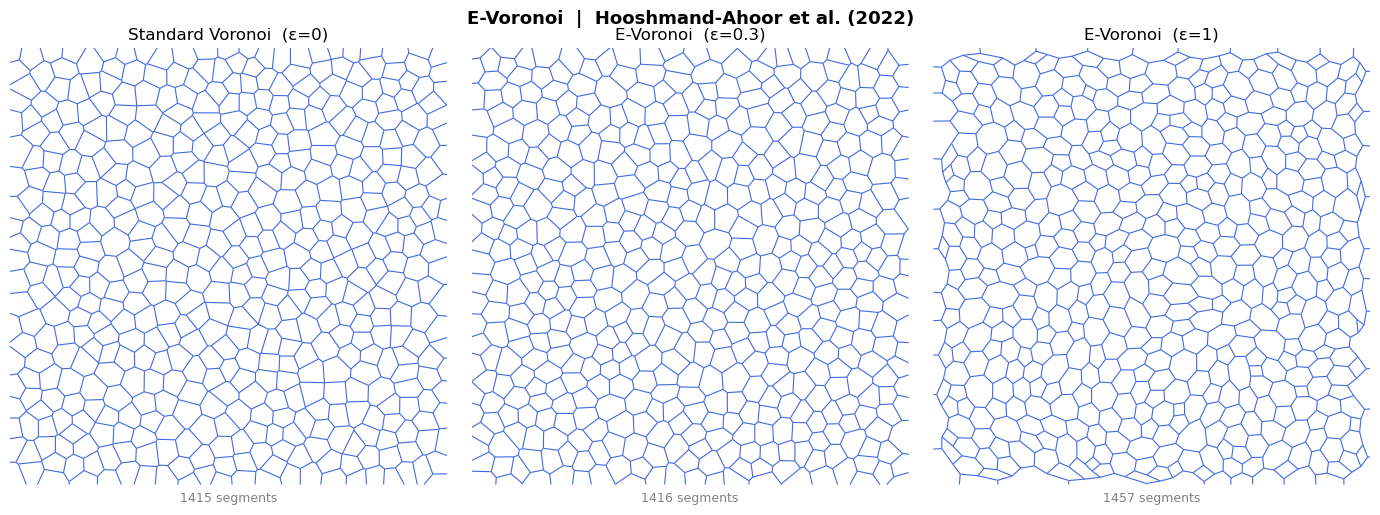

In [33]:
# ── Run: E-Voronoi — three erosion levels ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (eps, label) in zip(axes, [
    (0.0, 'Standard Voronoi  (ε=0)'),
    (0.3, 'E-Voronoi  (ε=0.3)'),
    (1, 'E-Voronoi  (ε=1)'),
]):
    segs, pts = generate_evoronoi(n_seeds=500, erosion=eps, seed=7)
    plot_beam_network(segs, pts, title=label, ax=ax, color='royalblue')
    ax.text(0.5, -0.04, f'{len(segs)} segments', ha='center',
            transform=ax.transAxes, fontsize=9, color='gray')

fig.suptitle('E-Voronoi  |  Hooshmand-Ahoor et al. (2022)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evoronoi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

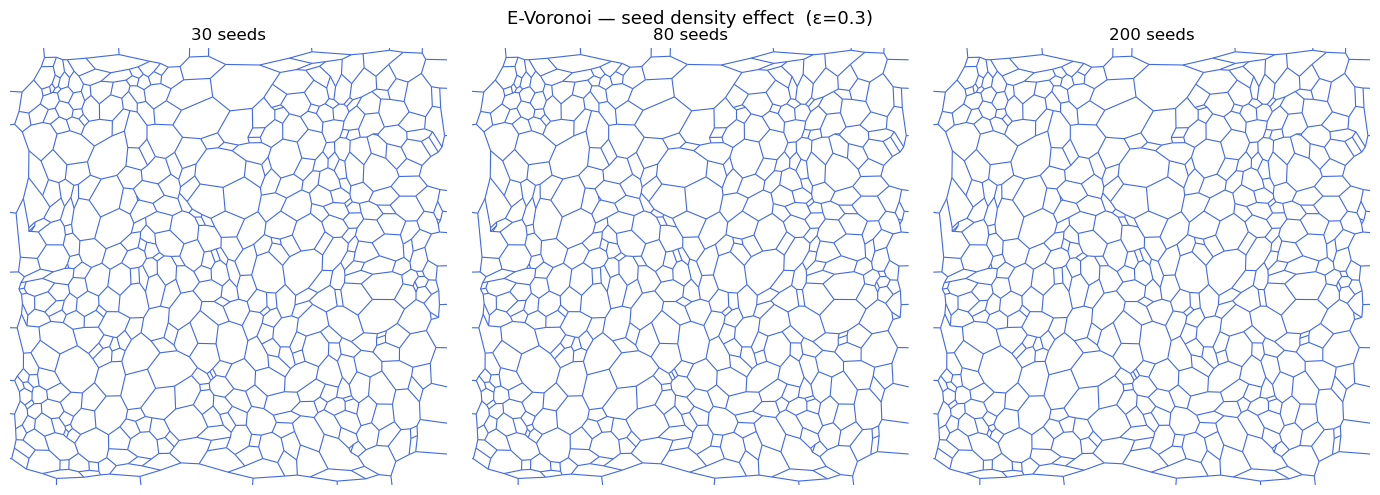

In [17]:
# ── Run: E-Voronoi — effect of seed density ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (n, label) in zip(axes, [
    (500,  '30 seeds'),
    (500,  '80 seeds'),
    (500, '200 seeds'),
]):
    segs, pts = generate_evoronoi(n_seeds=n, erosion=1, seed=42)
    plot_beam_network(segs, pts, title=label, ax=ax, color='royalblue')

fig.suptitle('E-Voronoi — seed density effect  (ε=0.3)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3  k-nearest Orthotropic Foam

A procedural, aperiodic beam network whose **orthotropy is controlled by a metric stretch $h_u$**.

### Algorithm (Martínez et al., 2017)
1. Place one jittered sample per cell of a virtual grid → crude Poisson-disc distribution.
2. Connect each point to its $k$ nearest neighbours under the **anisotropic distance**:

$$
d(p_i, p_j) = \frac{d_{p_i}(p_i,p_j) + d_{p_j}(p_j,p_i)}{2}, \qquad
d_{p_i}(p_i,p_j) = \sqrt{(p_i-p_j)^\top M(p_i)\,(p_i-p_j)}
$$

$$
M(p) = E^\top U E, \quad E = R(\theta), \quad U = \mathrm{diag}(h_u^{-2},\, h_v^{-2})
$$

For a **uniform** field the anisotropic kNN reduces to standard Euclidean kNN in the transformed space $T = \mathrm{diag}(h_u^{-1}, h_v^{-1})\cdot R(\theta)$.

In [29]:
# ── jittered-grid point distribution ─────────────────────────────────────────
def jittered_grid_points(grid_n, xmin=0, xmax=1, ymin=0, ymax=1, seed=42):
    """One random point per grid cell — approximates a Poisson-disc distribution."""
    rng = np.random.default_rng(seed)
    cx = np.linspace(xmin, xmax, grid_n + 1)
    cy = np.linspace(ymin-.015, ymax+.015, grid_n + 1)
    pts = []
    for i in range(grid_n):
        for j in range(grid_n):
            #if j == grid_n - 1:
            #    x = cx[i] + rng.random() * (cx[i+1] - cx[i])
            #    y = ymax
            
            #if j == 0:
            #    x = cx[i] + rng.random() * (cx[i+1] - cx[i])
            #    y = ymin
                
            #if j!= 0 and j!=grid_n-1:
            x = cx[i] + rng.random() * (cx[i+1] - cx[i])
            y = cy[j] + rng.random() * (cy[j+1] - cy[j])
            pts.append([x, y])

    return np.array(pts)

print('jittered_grid_points defined')

jittered_grid_points defined


In [30]:
# ── anisotropic metric transform ──────────────────────────────────────────────
def metric_transform(theta, hu, hv=1.0):
    """2x2 linear map T such that ||T(pi-pj)||_2 equals d_pi(pi,pj).
    For a uniform field, symmetric distance d(pi,pj) = ||T(pi-pj)||_2."""
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    S = np.diag([1.0 / hu, 1.0 / hv])
    return S @ R

print('metric_transform defined')

metric_transform defined


In [31]:
# ── k-nearest foam generator ──────────────────────────────────────────────────
def generate_knearest_foam(grid_n=20, k=6, theta=0.0, hu=1.0, hv=1.0, seed=42,
                            xmin=0, xmax=1, ymin=0, ymax=1):
    """
    Generate orthotropic k-nearest foam.

    Parameters
    ----------
    grid_n : grid resolution (grid_n × grid_n nodes)
    k      : number of nearest neighbours per node (paper uses k=6)
    theta  : orientation of principal stretch axis (radians)
    hu     : stretch factor along primary axis  (hu=1 → isotropic)
    hv     : stretch factor along secondary axis (fixed to 1 in the paper)
    seed   : random seed

    Returns
    -------
    segments : list of ((x1,y1),(x2,y2)) beam segments
    points   : (N,2) node positions
    """
    pts = jittered_grid_points(grid_n, xmin, xmax, ymin, ymax, seed)
    T   = metric_transform(theta, hu, hv)

    # Transform points into stretched space and run standard Euclidean kNN
    pts_T = (T @ pts.T).T
    tree  = cKDTree(pts_T)
    _, idx = tree.query(pts_T, k=k + 1)   # k+1: first result is the point itself

    edges = set()
    for i, neighbours in enumerate(idx):
        for j in neighbours[1:]:
            edges.add((min(i, j), max(i, j)))

    segments = [(tuple(pts[i]), tuple(pts[j])) for i, j in edges]
    return segments, pts

print('generate_knearest_foam defined')

generate_knearest_foam defined


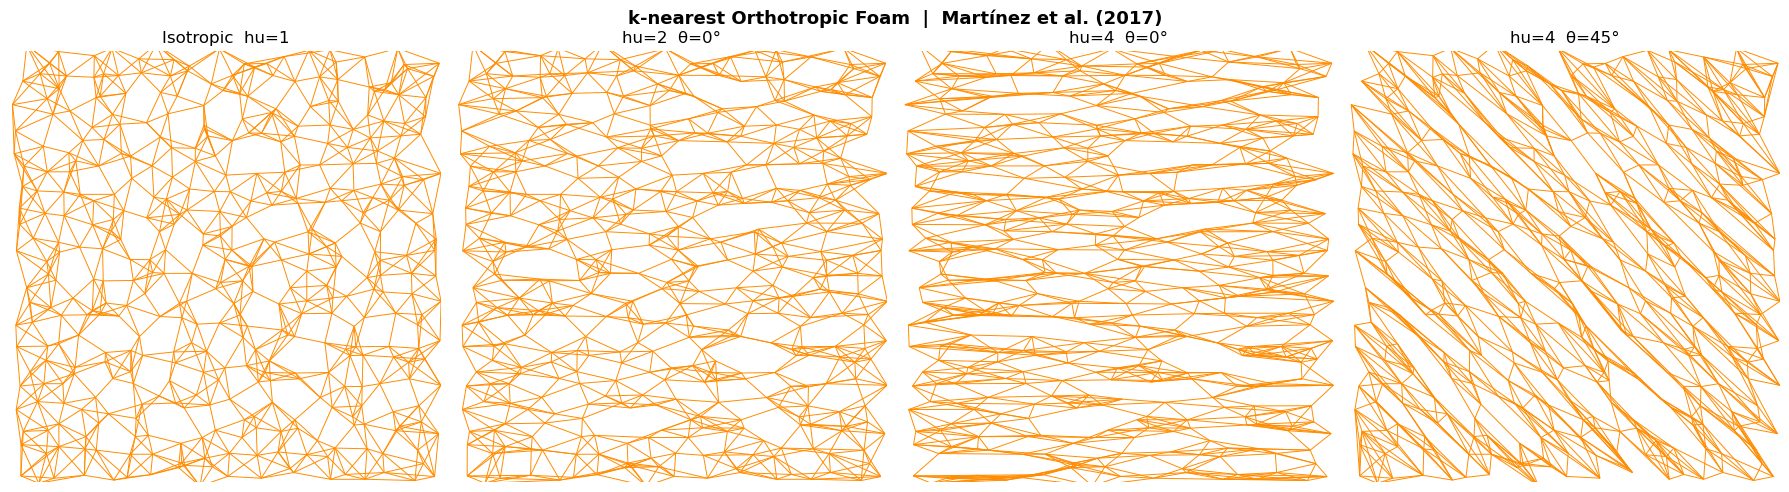

In [136]:
# ── Run: isotropic vs anisotropic foam ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (hu, th, lbl) in zip(axes, [
    (1.0, 0.0,       'Isotropic  hu=1'),
    (2.0, 0.0,       'hu=2  θ=0°'),
    (4.0, 0.0,       'hu=4  θ=0°'),
    (4.0, np.pi/4,   'hu=4  θ=45°'),
]):
    segs, pts = generate_knearest_foam(grid_n=20, k=6, theta=th, hu=hu, seed=99)
    plot_beam_network(segs, pts, title=lbl, ax=ax, color='darkorange', lw=0.7)

fig.suptitle('k-nearest Orthotropic Foam  |  Martínez et al. (2017)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('knearest_foam_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pickle
random_seeds = [1,2,3,4,5]
erosion_const = 1 
grid_n = 20
k=6
theta = 0
hu = 8


for rs in random_seeds:

    segs, pts = generate_knearest_foam(grid_n=grid_n, k=k, theta=theta, hu=hu, seed=rs)

    area = 0 
    polygon_dict = {}
    bounding_box = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])

    thickness = 0.0035

    for en, s in enumerate(segs):     
        
        poly = thicken_edge(s[0], s[1], thickness, bounding_box)
        poly_coord = poly.exterior.coords[:]
        if len(poly_coord) > 0:
            polygon_dict[en] = poly_coord

            area += poly.area

    file_name = 'k_Ortho_n'+str(grid_n)+'_k'+str(k)+'_h'+ str(hu)+'_ang'+str(theta) +'_rs'+str(rs)+'_d'+str(int(area*100))

    output = {'points':pts,
              'edeges':segs,
              'polygon_dict': polygon_dict}
    
    path = './'
    save_stl(polygon_dict, out_plane_thickness = .25, name = path+file_name+'.stl', frame_thickness=0.05)

    #save the polygon_dict to a pickle file
    with open(path+'input_'+file_name + '.pkl', 'wb') as f:
        pickle.dump(polygon_dict, f, protocol=2)

    with open(path+file_name + '.pkl', 'wb') as f:
        pickle.dump(output, f, protocol=2)

In [ ]:
#read pickle files
import glob
import pickle
import pandas as pd
random_seeds = [1,2,3,4,5]
erosion_const = 1 
grid_n = 20
k=6
theta = 0
hu = 1

files = glob.glob("/Users/csababoth/Work/3DNetwork/NetMat/ScaleRich_model/Code_mit/Code_1/Additional_Reference_systems/k_Ortho/k_Ortho*.pkl")
path = './'

for ff in files:

    file_name = ff.split('/k_Ortho/')[1].split('_d')[0]

    d = pd.read_pickle(ff)

    segs = d['edeges']
    pts = d['points']

    area = 0 
    polygon_dict = {}
    bounding_box = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])

    #thickness = 0.015
    #thickness_list = [0.005, 0.0075, 0.01,0.0125, 0.014]
    thickness_list = [0.002, 0.004, 0.006, 0.008, 0.01, 0.012]
    for thickness in thickness_list:
        for en, s in enumerate(segs):     
            
            poly = thicken_edge(s[0], s[1], thickness, bounding_box)
            poly_coord = poly.exterior.coords[:]
            if len(poly_coord) > 0:
                polygon_dict[en] = poly_coord

        #        area += poly.area
        
        #print(area)


        polygons = [Polygon(v) for v in polygon_dict.values()]
        union = unary_union(polygons)
        area = union.area


        new_file_name = file_name+'_d'+str(int(area*100))

        print(thickness, rs, area, new_file_name )

        

        output = {'points':pts,
                'edeges':segs,
                'polygon_dict': polygon_dict,
                'thickness': thickness,
                'area': area}
        
        save_stl(polygon_dict, out_plane_thickness = .25, name = path+new_file_name+'.stl', frame_thickness=0.05)

        #save the polygon_dict to a pickle file
        with open(path+'input_'+new_file_name + '.pkl', 'wb') as f:
            pickle.dump(polygon_dict, f, protocol=2)

        with open(path+new_file_name + '.pkl', 'wb') as f:
            pickle.dump(output, f, protocol=2)
            

0.002 5 0.18281414453199632 k_Ortho_n20_k6_h4_ang0_rs1_d18
0.004 5 0.31888356976358384 k_Ortho_n20_k6_h4_ang0_rs1_d31
0.006 5 0.4250224344433048 k_Ortho_n20_k6_h4_ang0_rs1_d42
0.008 5 0.5089072205815687 k_Ortho_n20_k6_h4_ang0_rs1_d50
0.01 5 0.5760361333400535 k_Ortho_n20_k6_h4_ang0_rs1_d57
0.012 5 0.6308346573318367 k_Ortho_n20_k6_h4_ang0_rs1_d63
0.002 5 0.14546503947095904 k_Ortho_n20_k6_h1_ang0_rs2_d14
0.004 5 0.26596475121019103 k_Ortho_n20_k6_h1_ang0_rs2_d26
0.006 5 0.36700542359334304 k_Ortho_n20_k6_h1_ang0_rs2_d36
0.008 5 0.4521768114232749 k_Ortho_n20_k6_h1_ang0_rs2_d45
0.01 5 0.5242417595208811 k_Ortho_n20_k6_h1_ang0_rs2_d52
0.012 5 0.5853681807759414 k_Ortho_n20_k6_h1_ang0_rs2_d58
0.002 5 0.2302550095677299 k_Ortho_n20_k6_h8_ang0_rs3_d23
0.004 5 0.38007728733654456 k_Ortho_n20_k6_h8_ang0_rs3_d38
0.006 5 0.4849495208863276 k_Ortho_n20_k6_h8_ang0_rs3_d48
0.008 5 0.5625753668968042 k_Ortho_n20_k6_h8_ang0_rs3_d56
0.01 5 0.6224931727187367 k_Ortho_n20_k6_h8_ang0_rs3_d62
0.012 5 0.6